# 01 · Data Understanding

Exploratory analysis of the raw transactions and customers datasets.
Run **after** `make samples` to generate the source CSVs.


In [1]:
import sys
from pathlib import Path
ROOT = Path().resolve().parent
sys.path.insert(0, str(ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.facecolor'] = '#f9fafb'
import seaborn as sns

print('Libraries loaded ')

Libraries loaded 


## 1. Load raw data

In [2]:
tx = pd.read_csv(ROOT / 'data/samples/transactions.csv', low_memory=False)
cu = pd.read_csv(ROOT / 'data/samples/customers.csv')
print(f'Transactions : {len(tx):,} rows  x  {len(tx.columns)} cols')
print(f'Customers    : {len(cu):,} rows  x  {len(cu.columns)} cols')

Transactions : 5,025 rows  x  10 cols
Customers    : 3,351 rows  x  5 cols


## 2. Schema overview

In [3]:
print('=== TRANSACTIONS ===')
tx.info()
print()
tx.head(3)

=== TRANSACTIONS ===
<class 'pandas.DataFrame'>
RangeIndex: 5025 entries, 0 to 5024
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   InvoiceNo      5025 non-null   str    
 1   StockCode      5025 non-null   str    
 2   Description    5025 non-null   str    
 3   Quantity       5025 non-null   int64  
 4   InvoiceDate    5025 non-null   str    
 5   UnitPrice      5009 non-null   float64
 6   CustomerID     4855 non-null   str    
 7   Country        5025 non-null   str    
 8   Status         5025 non-null   str    
 9   PaymentMethod  5025 non-null   str    
dtypes: float64(1), int64(1), str(8)
memory usage: 392.7 KB



,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Status,PaymentMethod
0,566797,71053,WHITE METAL LANTERN,-4,2023-10-15 23:45:05,3.39,C14253,Finland,completed,card
1,C518293,71053,WHITE METAL LANTERN,8,2023-04-01 08:33:24,3.39,C16139,Austria,completed,card
2,C502796,85123A,WHITE HANGING HEART T-LIGHT HOLDER,43,2023-11-09 22:46:47,2.55,C13307,France,completed,card


In [4]:
print('=== CUSTOMERS ===')
cu.info()
print()
cu.head(3)

=== CUSTOMERS ===
<class 'pandas.DataFrame'>
RangeIndex: 3351 entries, 0 to 3350
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   CustomerID  3351 non-null   str  
 1   Country     3351 non-null   str  
 2   SignupDate  3324 non-null   str  
 3   Segment     3351 non-null   str  
 4   IsActive    3351 non-null   bool 
dtypes: bool(1), str(4)
memory usage: 108.1 KB



,CustomerID,Country,SignupDate,Segment,IsActive
0,C14253,Japan,2019-11-11,online,False
1,C16139,Portugal,2018-12-30,retail,True
2,C13307,Japan,2018-10-19,online,True


## 3. Missing values

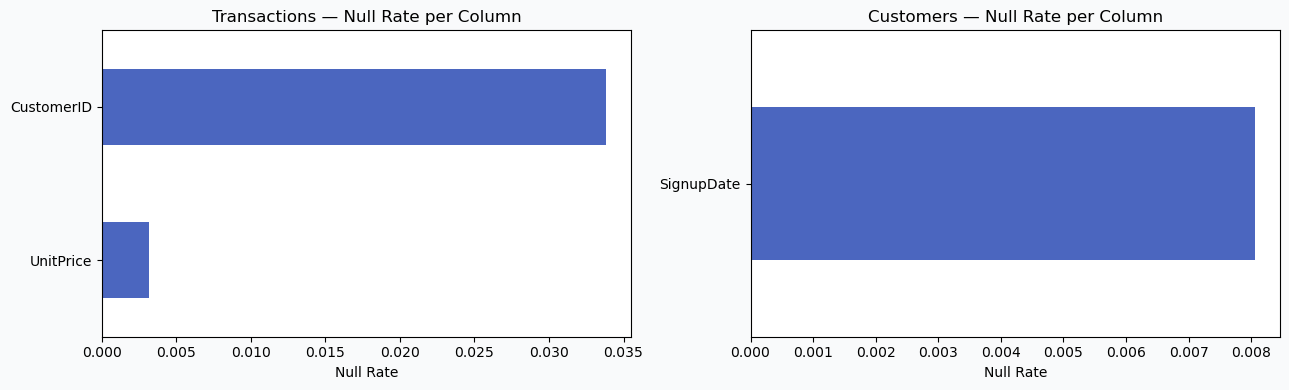

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, df, name in zip(axes, [tx, cu], ['Transactions', 'Customers']):
    null_pct = df.isna().mean().sort_values(ascending=True)
    null_pct[null_pct > 0].plot.barh(ax=ax, color='#1e40af', alpha=0.8)
    ax.set_title(f'{name} — Null Rate per Column')
    ax.set_xlabel('Null Rate')
plt.tight_layout()
plt.show()

## 4. Duplicate analysis

In [6]:
print('Transaction duplicates (InvoiceNo):', tx['InvoiceNo'].duplicated().sum())
print('Transaction duplicates (InvoiceNo+StockCode):', tx.duplicated(subset=['InvoiceNo','StockCode']).sum())
print('Customer duplicates  (CustomerID):', cu['CustomerID'].duplicated().sum())

Transaction duplicates (InvoiceNo): 94
Transaction duplicates (InvoiceNo+StockCode): 29
Customer duplicates  (CustomerID): 20


## 5. Distributions

In [7]:
tx['UnitPrice'] = pd.to_numeric(tx['UnitPrice'], errors='coerce')
tx['Quantity']  = pd.to_numeric(tx['Quantity'],  errors='coerce')
print(tx[['UnitPrice','Quantity']].describe().round(2))

       UnitPrice  Quantity
count    5009.00   5025.00
mean        3.60     22.48
std         1.68     16.32
min        -1.50     -5.00
25%         2.55      8.00
50%         3.39     22.00
75%         4.25     37.00
max         7.65     50.00


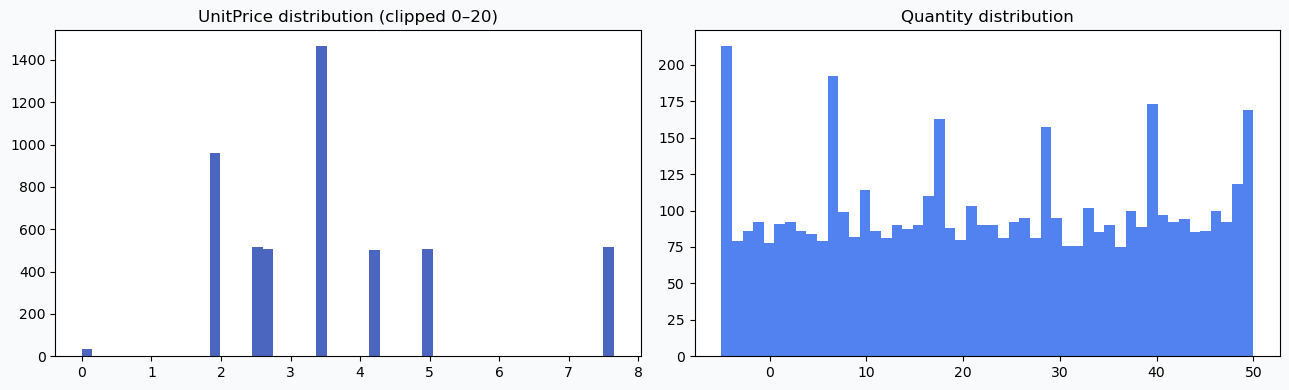

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(tx['UnitPrice'].clip(0,20).dropna(), bins=50, color='#1e40af', alpha=0.8)
axes[0].set_title('UnitPrice distribution (clipped 0–20)')
axes[1].hist(tx['Quantity'].clip(-20,50).dropna(), bins=50, color='#2563eb', alpha=0.8)
axes[1].set_title('Quantity distribution')
plt.tight_layout(); plt.show()

## 6. Country & date coverage

In [9]:
print('Top 10 countries by transaction count:')
print(tx['Country'].value_counts().head(10).to_string())

Top 10 countries by transaction count:
Country
Sweden            274
Austria           272
Norway            266
France            262
Canada            262
Netherlands       261
Finland           258
United Kingdom    257
Spain             254
Switzerland       254


In [10]:
tx['InvoiceDate'] = pd.to_datetime(tx['InvoiceDate'], errors='coerce')
print('Date range:', tx['InvoiceDate'].min(), '→', tx['InvoiceDate'].max())
print('Future dates:', (tx['InvoiceDate'] > pd.Timestamp.now()).sum())
print('Null dates:  ', tx['InvoiceDate'].isna().sum())

Date range: 2023-01-01 00:43:35 → 2099-01-01 00:00:00
Future dates: 18
Null dates:   0
